# Stack Overflow Developer Survey — EDA Portfolio

**Theme 1:** AI Adoption x Compensation | **Theme 2:** AI Adoption x Tech Stack

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
from pathlib import Path

# Paths (relative to notebooks/)
DATASET = Path('../dataset/so_dev_survey.csv')
IMG = Path('../img')
IMG.mkdir(exist_ok=True)

# Global style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

TEAL  = '#2a9d8f'
CORAL = '#e76f51'

In [2]:
df = pd.read_csv(DATASET)
print(f"Shape: {df.shape}")
df.head(2)

Shape: (1882, 172)


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0


## Section 1 — Data Quality Summary

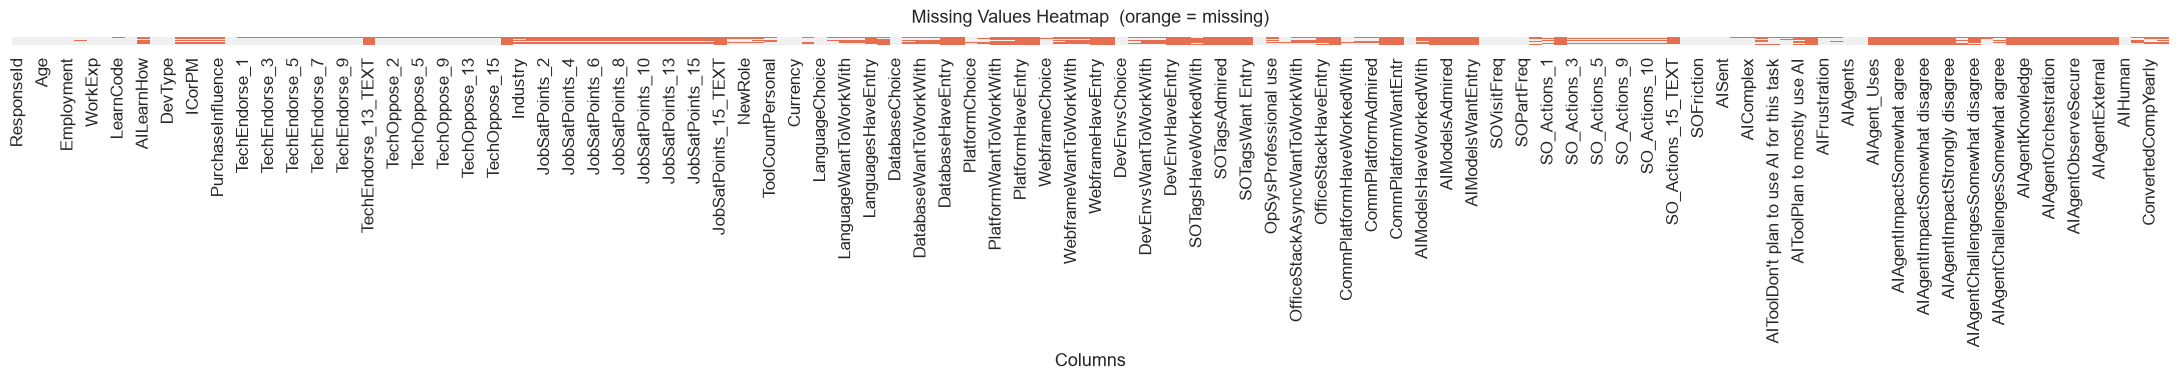

In [3]:
fig, ax = plt.subplots(figsize=(22, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
            cmap=['#f0f0f0', '#e76f51'], ax=ax)
ax.set_title('Missing Values Heatmap  (orange = missing)', fontsize=13, pad=10)
ax.set_xlabel('Columns')
plt.tight_layout()
plt.show()

In [4]:
quality = pd.DataFrame({
    'dtype'     : df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct'  : (df.isnull().sum() / len(df) * 100).round(1),
}).sort_values('null_pct', ascending=False)

print(f"Total rows    : {len(df):,}")
print(f"Total columns : {len(df.columns)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
quality.head(20)

Total rows    : 1,882
Total columns : 172
Duplicate rows: 0


,dtype,null_count,null_pct
SO_Actions_16,float64,1882,100.0
SOTagsWant Entry,str,1863,99.0
AIAgentObsWrite,str,1864,99.0
SOTagsHaveEntry,str,1861,98.9
AIModelsWantEntry,str,1861,98.9
AIAgentOrchWrite,str,1855,98.6
JobSatPoints_15_TEXT,str,1848,98.2
AIModelsHaveEntry,str,1844,98.0
AIAgentExtWrite,str,1843,97.9
AIAgentKnowWrite,str,1836,97.6


In [5]:
# Coerce numeric columns that may contain strings
for c in ['YearsCode', 'WorkExp']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df[['ConvertedCompYearly', 'YearsCode', 'WorkExp']].describe().round(0)

,ConvertedCompYearly,YearsCode,WorkExp
count,1380.0,1866.0,1862.0
mean,105065.0,20.0,16.0
std,89095.0,12.0,12.0
min,1.0,1.0,1.0
25%,49741.0,10.0,7.0
50%,89331.0,17.0,14.0
75%,140000.0,28.0,24.0
max,928117.0,63.0,60.0
